<a href="https://colab.research.google.com/github/embark-cybertraining/embark-scratch-notebooks/blob/main/sessions_1_and_2/ooi_cruises_bcodmo_session1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prototype notebook for EMBARK CyberTraining Session 1

## Use Case Goal:

An oceanographer would like to visualize salinity by depth at a deep ocean study site with multiple cruises over several years.
As a CI user, s/he will (find), access, and use data from external sources to plot salinity by depth over a several-year time period for a location in which some of the profiles were collected by ship-based CTD rosette casts and others were sensed by Argo floats.

* Data repositories: BCO-DMO, NCEI
* Ocean observing systems: Argo, U.S. NSF OOI

* Tools include: ERDDAP, Python software libraries (e.g., pandas, erddapy, argopy)

This notebook may be run locally, or within cloud-based computing infrastructure (e.g., Google Colab, OOI JupyterHub).

## Session 1 (this notebook)
Visualize 10 years of discrete water sampling data from annual research cruises and overlay with post-calibrated, ship-cast CTD profiles
## Session 2 (in a separate notebook)
Fill in the time gaps between research cruises with CTD profile data from autonomous floats

## Credits for this notebook
* The first portion builds on a notebook from the OOI CGSN Data Team https://github.com/WHOIGit/ooi-on-bco-dmo/blob/main/notebooks/0-OOI-Irminger-discrete-sample-article-figures.ipynb
* Overall the notebook was developed by the EMBARK CyberTraining project team, including Amber York, Sage Lichtenwalner, and Stace Beaulieu.
* Where indicated, some code was generated or improved by AI coding assistance, including ChatGPT.

# Setup

In [91]:
# Install any missing libraries into the current environment.
#   will leave any already installed packages alone if they satisfy requirements.
%pip install -q pandas matplotlib cmocean folium erddapy

In [92]:
# Import modules so we can use them in our code
#    does not yet include argopy, plotly, numpy for Session 2
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib.dates import AutoDateLocator, AutoDateFormatter
import folium
from erddapy import ERDDAP
import cmocean.cm as cmo # colormaps for commonly-used oceanographic variables
# consider remove the cmocean package and just use viridis

# SESSION 1
Visualize 10 years of discrete water sampling data from annual research cruises and overlay with post-calibrated, ship-cast CTD profiles

We will use cruises to the U.S. NSF OOI Global Irminger Sea Array https://oceanobservatories.org/array/global-irminger-sea-array/.

Discrete water samples were collected not only for post-cal'g ship-cast CTD sensors but also for in situ mooring-mounted sensors.

# DATASET 1 - Discrete water sampling data from research cruises

## Find Data
The CI user already will have used other tools to search for "Irminger Sea discrete water sampling" and find:
* Dataset: OOI Global Irminger Sea Array CTD and Discrete Water Sampling Data from Mooring Overturning Cruises in the Irminger Sea from 2014-2023 (OOI Cruise Data project)
* **Dataset Landing Page: https://www.bco-dmo.org/dataset/911407**



## Inspect data/metadata for context


Inspect the dataset landing page metadata for context for your analysis.

This dataset also is provided through ERDDAP; you can use the ERDDAP Make A Graph tool to confirm your desired location, time period, and parameters are in the dataset: https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.graph




### Review the data license

Check the license to make sure your intended use is allowed.

### Access Strategies

To access the data, one can:
1. Access the File through the URL. For example, on the Dataset Landing Page https://www.bco-dmo.org/dataset/911407 (copy csv download link).
2. Access a data table from an ERDDAP URL. Generate a URL using the [ERDDAP Data Access Form](https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.html)
      - If using the ERDDAP Data Access Form, file type .csvp provides a single header row.
      - Note: If using the ERDDAP Data Access Form, one can subset (e.g., select variables of interest, and ranges within variables) prior to loading the data.
3. Access data from ERDDAP using a software library called erdappy.

# Access Strategy 1: Load from a file using a URL

In [93]:
# link to the public dataset CSV
# link obtained by copying the download button for the csv Data file showing on
# Dataset Landing Page https://www.bco-dmo.org/dataset/911407

bcodmo_data_url = "https://datadocs.bco-dmo.org/dataset/911407/file/vmvAX9NU4gqY2V/911407_v1_ooi_irminger_sea_discrete_water_sampling_data.csv"

# Load the OOI data into a dataframe
df_ctd_discr_all = pd.read_csv(bcodmo_data_url)

# Call head() to check that the data was imported correctly
df_ctd_discr_all.head()

,Cruise,Station,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Cast_Flag,Bottom_Depth_at_Start_Position,CTD_File,...,Discrete_pH_Replicate_Flag,Calculated_Alkalinity,Calculated_DIC,Calculated_pCO2,Calculated_pH,Calculated_CO2aq,Calculated_Bicarb,Calculated_CO3,Calculated_Omega_C,Calculated_Omega_A
0,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
#This shows all the columns in your pandas data frame as well as
#   count of values (non-null), and data types

df_ctd_discr_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1937 entries, 0 to 1936
Data columns (total 80 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Cruise                                1937 non-null   object 
 1   Station                               1937 non-null   object 
 2   Target_Asset                          1937 non-null   object 
 3   Start_Latitude                        1937 non-null   float64
 4   Start_Longitude                       1937 non-null   float64
 5   Start_Time                            1937 non-null   object 
 6   Cast                                  1937 non-null   object 
 7   Cast_Flag                             1936 non-null   object 
 8   Bottom_Depth_at_Start_Position        1864 non-null   float64
 9   CTD_File                              1901 non-null   object 
 10  CTD_File_Flag                         1900 non-null   object 
 11  Niskin_Bottle_Pos

note the first rows of the data indicate a test cast outside of our desired study area

## Quality control
For functions to interpret OOI discrete sample CTD flags to QARTOD QC-flags please see bottles.py file in https://github.com/oceanobservatories/ooi-data-explorations.

In [95]:
# display unique Discrete Salinity Sample quality flags
df_ctd_discr_all.Discrete_Salinity_Flag.unique() # display unique for parameter of interest
# pd.unique(ooi_irm[["Discrete_Oxygen_Flag", "Discrete_Salinity_Flag", "Discrete_Nutrients_Flag"]].values.ravel('K')) # display unique multiple columns

array([nan, '*0000000000000100', '*0000000000001001', '*0000000000000101'],
      dtype=object)

In [96]:
# We want to limit our data to only where Discrete_Salinity is good data.
# For these quality flags, acceptable data is anywhere a 1 is in the third to last position:
# examples:  "*0000000000000100"
#                  or
#            "*0000000000000101"

# make a new "qc" df with only rows where
#   the salinity flag has a 1 in the third-from-last position
df_ctd_discr_all_qc = df_ctd_discr_all.query(
    "Discrete_Salinity_Flag.str[-3] == '1'",
    engine="python"
)

print(
    f"This subset of Discrete Samples with Acceptable flags reduced the total data points\n    from "
    f"{len(df_ctd_discr_all)} to {len(df_ctd_discr_all_qc)}"
)

This subset of Discrete Samples with Acceptable flags reduced the total data points
    from 1937 to 1072


In [97]:
# double check we only have "good" flags now
df_ctd_discr_all_qc.Discrete_Salinity_Flag.unique()

array(['*0000000000000100', '*0000000000000101'], dtype=object)

In [98]:
# Call head() to view subset of Discrete Samples with Acceptable flags
df_ctd_discr_all_qc.head()

,Cruise,Station,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Cast_Flag,Bottom_Depth_at_Start_Position,CTD_File,...,Discrete_pH_Replicate_Flag,Calculated_Alkalinity,Calculated_DIC,Calculated_pCO2,Calculated_pH,Calculated_CO2aq,Calculated_Bicarb,Calculated_CO3,Calculated_Omega_C,Calculated_Omega_A
12,KN221-04,2,Test Site #2,61.995333,-31.8725,2014-09-08T14:44:00.000Z,2,*0000000000000100,2698.0,KN22104002.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,KN221-04,2,Test Site #2,61.995333,-31.8725,2014-09-08T14:44:00.000Z,2,*0000000000000100,2698.0,KN22104002.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,KN221-04,2,Test Site #2,61.995333,-31.8725,2014-09-08T14:44:00.000Z,2,*0000000000000100,2698.0,KN22104002.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,KN221-04,2,Test Site #2,61.995333,-31.8725,2014-09-08T14:44:00.000Z,2,*0000000000000100,2698.0,KN22104002.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,KN221-04,2,Test Site #2,61.995333,-31.8725,2014-09-08T14:44:00.000Z,2,*0000000000000100,2698.0,KN22104002.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


note the first rows of this particular subset of data still indicate a test cast outside of our desired study area


If we do not subset to our desired region of interest, the first plot over time that we make below will include irrelevant data.
We could proceed with the next code cell to subset to our desired region of interest.

## Cleaning

Remove rows that have blank times or salinities.


In [99]:
# Drop any rows that have NA for CTD_Bottle_Closure_Time
df_ctd_discr_all_qc = df_ctd_discr_all_qc.dropna(subset=["CTD_Bottle_Closure_Time"])

print("Number of records after dropping any blank time rows (if any):")
len(df_ctd_discr_all_qc["CTD_Bottle_Closure_Time"])

Number of records after dropping any blank time rows (if any):


1072

In [100]:
# Drop any rows that have NA for "Discrete_Salinity"
df_ctd_discr_all_qc = df_ctd_discr_all_qc.dropna(subset=["Discrete_Salinity"])

print("Number of records after dropping any blank salinity rows (if any):")
len(df_ctd_discr_all_qc["Discrete_Salinity"])

Number of records after dropping any blank salinity rows (if any):


1071

## Convert relevant parameters to datetime if needed

In [101]:
# Convert the CTD Bottle Closure Time to a datetime data type
df_ctd_discr_all_qc["CTD_Bottle_Closure_Time"] = pd.to_datetime(df_ctd_discr_all_qc["CTD_Bottle_Closure_Time"], yearfirst=True, utc=True)
df_ctd_discr_all_qc.dtypes["CTD_Bottle_Closure_Time"]

datetime64[ns, UTC]

In [102]:
# # Keep this cell to demonstrate efficiency using ERDDAP to subset prior to loading data
# # Use code within notebook to subset to just the area (and time) of interest
# # Bounds
# LON_MIN, LON_MAX = -40, -39
# LAT_MIN, LAT_MAX = 59.5, 60.5
# TIME_MIN, TIME_MAX = "2018-01-01", "2021-12-31"

# # Ensure we are not working on a view
# irm_qc = irm_qc.copy()

# irm_qc.loc[:, "CTD_Bottle_Closure_Time"] = pd.to_datetime(
#     irm_qc["CTD_Bottle_Closure_Time"], yearfirst=True, utc=True, errors="coerce"
# )

# tmin = pd.to_datetime(TIME_MIN, utc=True)
# tmax = pd.to_datetime(TIME_MAX, utc=True)

# ooi_subset = irm_qc.loc[
#     (irm_qc["CTD_Bottle_Closure_Time"] >= tmin) &
#     (irm_qc["CTD_Bottle_Closure_Time"] <= tmax) &
#     (irm_qc["Start_Latitude"] >= LAT_MIN) &
#     (irm_qc["Start_Latitude"] <= LAT_MAX) &
#     (irm_qc["Start_Longitude"] >= LON_MIN) &
#     (irm_qc["Start_Longitude"] <= LON_MAX)
# ].copy().reset_index(drop=True)

# ooi_subset

# # Would need to recompute QC masks on the subset (moved to below)

## Visualize data

##### Set themes, styles, and figure global parameters

In [103]:
# Assign colormaps from cmocean package
#cmap_oxy = cmo.deep_r
cmap_salt = cmo.haline
#cmap_nitr = cmo.matter
#cmap_chl = cmo.algae
cmap_time = cmo.tempo_r

In [104]:
# set up time for matplotlib plots
discrete_time = df_ctd_discr_all_qc["CTD_Bottle_Closure_Time"].values

# Create a matplotlib-friendly numeric time array
discrete_mpl_time = mpl.dates.date2num(discrete_time)

# Create normalizer for colorbar representing the full date range
normalizer = Normalize(discrete_mpl_time[0], discrete_mpl_time[-1])

# Create tick locator for using time as the color scale
locator = AutoDateLocator()

In [105]:
# Look at sal max and min before QC
salmax_all = df_ctd_discr_all["Discrete_Salinity"].max()
salmin_all = df_ctd_discr_all["Discrete_Salinity"].min()
print(f"Max: {salmax_all} | Min: {salmin_all}")

Max: 44.2486 | Min: 33.153


In [106]:
# Look at sal max and min after QC
#  lets us see the max min for parameter of interest
salmax_all_qc = df_ctd_discr_all_qc["Discrete_Salinity"].max()
salmin_all_qc = df_ctd_discr_all_qc["Discrete_Salinity"].min()
print(f"Max: {salmax_all_qc} | Min: {salmin_all_qc}")


Max: 35.7298 | Min: 33.153


#### Plot QC'd Data

**Figure** Plot the salinity over time as a function of depth

Text(0.5, 0, 'Time')

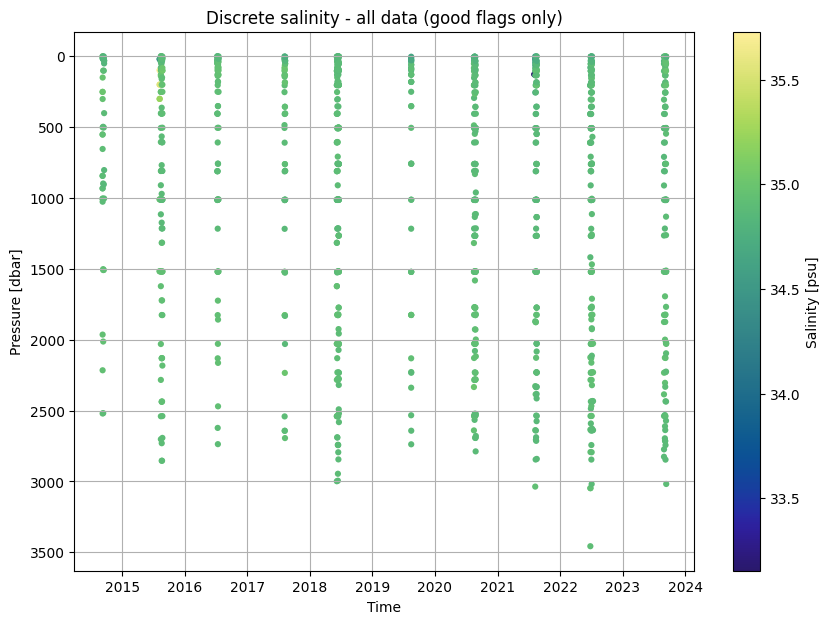

In [131]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.invert_yaxis()
plt.scatter(x=discrete_time,
            y=df_ctd_discr_all_qc["CTD_Pressure"],
            s=20,
            c=df_ctd_discr_all_qc["Discrete_Salinity"],
            cmap=cmap_salt,
            edgecolors="none",
            vmin=salmin_all_qc,
            vmax=salmax_all_qc)
plt.grid()
plt.colorbar(label="Salinity [psu]")
plt.title("Discrete salinity - all data (good flags only)")

ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")

Dataset 1: Quick map visualization prior to geographic subsetting

Note: this activity is situated at the end of Session 1: 1st breakout; it would more naturally fit earlier but we want the 1st breakout to achieve the salinity by depth plot.

In [108]:
# Show where all the good data are
# * code in this cell was generated by ChatGPT
import folium
from folium import LatLngPopup

# Remove rows with missing coordinates
df = df_ctd_discr_all_qc.dropna(subset=["Start_Latitude", "Start_Longitude"])

# Center map on the average location
center_lat = df["Start_Latitude"].mean()
center_lon = df["Start_Longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8
)

# Add points
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["Start_Latitude"], row["Start_Longitude"]],
        radius=3,
        color="blue",
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m.add_child(LatLngPopup())

m

# Access Strategy 2: Loading a subset using a URL pattern (ERDDAP URL)


### Generate a URL using the [ERDDAP Data Access Form](https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.html)
If using the ERDDAP Data Access Form, file type .csvp provides a single header row.

If using the ERDDAP Data Access Form, one can subset (e.g., select variables of interest, and ranges within) prior to loading the data.

[Example of the form filled out with our subset selections](https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.html?Cruise%2CTarget_Asset%2CStart_Latitude%2CStart_Longitude%2CStart_Time%2CCast%2CNiskin_Bottle_Position%2CCTD_Bottle_Closure_Time%2CCTD_Pressure%2CCTD_Pressure_Flag%2CDiscrete_Salinity%2CDiscrete_Salinity_Flag&Start_Latitude%3E=59.5&Start_Latitude%3C=60.5&Start_Longitude%3E=-40&Start_Longitude%3C=-39&Discrete_Salinity!=NaN&Discrete_Salinity_Flag=~%22.*1%5B0-9%5D%7B2%7D%24%22)

In [139]:
# load ooi_subset from ERDDAP
# then do steps above for disc sal qc to make this new dataframe equivalent to relevant content within ooi_subset from coding within cell above
erddap_url = "https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.csv?Cruise%2CTarget_Asset%2CStart_Latitude%2CStart_Longitude%2CStart_Time%2CCast%2CNiskin_Bottle_Position%2CCTD_Bottle_Closure_Time%2CCTD_Pressure%2CCTD_Pressure_Flag%2CDiscrete_Salinity%2CDiscrete_Salinity_Flag&Start_Latitude%3E=59.5&Start_Latitude%3C=60.5&Start_Longitude%3E=-40&Start_Longitude%3C=-39&Discrete_Salinity!=NaN&Discrete_Salinity_Flag=~%22.*1%5B0-9%5D%7B2%7D%24%22"

# Load the data subset into a dataframe
# skiprows is used here because ERDDAP provides the second row with units,
#   we just want column names followed by data rows so we are skipping units row.
#   We can refer to the dataset metadata to find the units.
df_ctd_discr_spatial_erddap_url_qc = pd.read_csv(erddap_url, skiprows=[1])

# Call head() to check that the data was read in correctly
df_ctd_discr_spatial_erddap_url_qc.head()

# Note: In our subset url (form selection) we already said we only want where the "good" salinity flags are
#   so this is already limited to just where the QARTOD flags are acceptable (1 in the third to last position like *0000000000000100)

,Cruise,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Niskin_Bottle_Position,CTD_Bottle_Closure_Time,CTD_Pressure,CTD_Pressure_Flag,Discrete_Salinity,Discrete_Salinity_Flag
0,KN221-04,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,2,2014-09-11T23:17:06.000Z,1502.957,*0000000000000100,34.9323,*0000000000000100
1,KN221-04,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,4,2014-09-11T23:28:19.000Z,899.222,*0000000000000100,34.8664,*0000000000000100
2,KN221-04,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,6,2014-09-11T23:36:09.000Z,499.163,*0000000000000100,34.8934,*0000000000000100
3,KN221-04,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,10,2014-09-11T23:44:22.000Z,103.228,*0000000000000100,34.9467,*0000000000000100
4,KN221-04,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,18,2014-09-11T23:49:34.000Z,14.837,*0000000000000100,34.7811,*0000000000000100


In [140]:
df_ctd_discr_spatial_erddap_url_qc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Cruise                   698 non-null    object 
 1   Target_Asset             698 non-null    object 
 2   Start_Latitude           698 non-null    float64
 3   Start_Longitude          698 non-null    float64
 4   Start_Time               698 non-null    object 
 5   Cast                     698 non-null    int64  
 6   Niskin_Bottle_Position   698 non-null    int64  
 7   CTD_Bottle_Closure_Time  698 non-null    object 
 8   CTD_Pressure             698 non-null    float64
 9   CTD_Pressure_Flag        698 non-null    object 
 10  Discrete_Salinity        698 non-null    float64
 11  Discrete_Salinity_Flag   698 non-null    object 
dtypes: float64(4), int64(2), object(6)
memory usage: 65.6+ KB


In [141]:
print("Number of records after dropping any blank time rows (if any)")
df_ctd_discr_spatial_erddap_url_qc = df_ctd_discr_spatial_erddap_url_qc.dropna(subset=["CTD_Bottle_Closure_Time"])
len(df_ctd_discr_spatial_erddap_url_qc["CTD_Bottle_Closure_Time"])

Number of records after dropping any blank time rows (if any)


698

In [142]:
# Convert the CTD Bottle Closure Time to a datetime data type
df_ctd_discr_spatial_erddap_url_qc["CTD_Bottle_Closure_Time"] = pd.to_datetime(df_ctd_discr_spatial_erddap_url_qc["CTD_Bottle_Closure_Time"], yearfirst=True, utc=True)
df_ctd_discr_spatial_erddap_url_qc.dtypes["CTD_Bottle_Closure_Time"]

datetime64[ns, UTC]

In [143]:
# Checking Quality flags.
#  Since our data subset asked for only QARTOD flags that mean
#  acceptable data (1 in third to last position)
#  let's just make sure that's all we have

# display unique Discrete Sample flags
df_ctd_discr_spatial_erddap_url_qc.Discrete_Salinity_Flag.unique() # display unique for parameter of interest

array(['*0000000000000100'], dtype=object)

## Repeat visualize

In [144]:
# steps as above but for new dataframe
# set up time for matplotlib plots (subset of data)
discrete_time_subset = df_ctd_discr_spatial_erddap_url_qc["CTD_Bottle_Closure_Time"].values

# Create a matplotlib-friendly numeric time array
discrete_mpl_time_subset = mpl.dates.date2num(discrete_time_subset)

# Create normalizer for colorbar representing the full date range
normalizer_subset = Normalize(discrete_mpl_time_subset[0], discrete_mpl_time_subset[-1])

# Create tick locator for using time as the color scale
locator_subset = AutoDateLocator()


In [116]:
# determine max min for parameter of interest
salmax_erddap_url_qc = df_ctd_discr_spatial_erddap_url_qc["Discrete_Salinity"].max()
salmin_erddap_url_qc = df_ctd_discr_spatial_erddap_url_qc["Discrete_Salinity"].min()
print(f"Max: {salmax_erddap_url_qc} | Min: {salmin_erddap_url_qc}")


Max: 35.0303 | Min: 34.5686


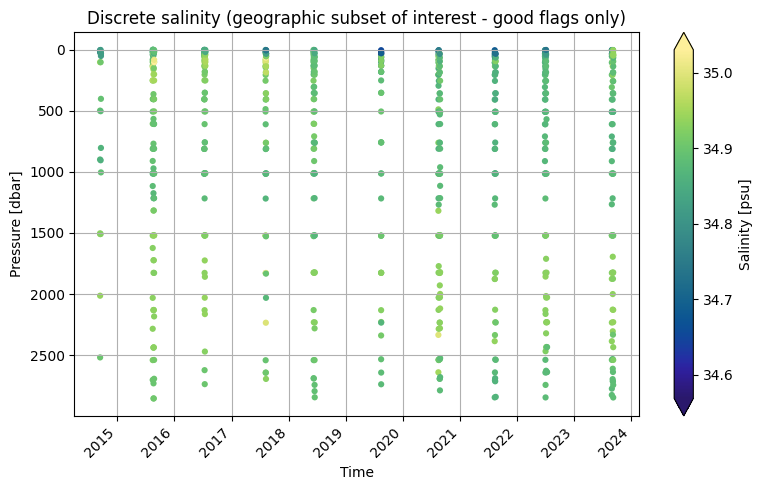

In [117]:
# plot code from JP class differs from initial plot code above
plt.figure(figsize=(8, 5))

plt.scatter(
    x=df_ctd_discr_spatial_erddap_url_qc["CTD_Bottle_Closure_Time"],
    y=df_ctd_discr_spatial_erddap_url_qc["CTD_Pressure"],
    s=20,
    c=df_ctd_discr_spatial_erddap_url_qc["Discrete_Salinity"],
    cmap=cmo.haline,  # colormap from cmocean, designed for salinity (perceptually uniform, accessible colors)
    edgecolors="none",
    vmin=salmin_erddap_url_qc, # use salmin
    vmax=salmax_erddap_url_qc # use salmax
)

plt.gca().invert_yaxis()
plt.grid()
plt.colorbar(label="Salinity [psu]")
plt.ylabel("Pressure [dbar]")
plt.xlabel("Time")
plt.title("Discrete salinity (geographic subset of interest - good flags only)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

# Access Strategy 3: Loading the same subset as strategy 2, but this time use the library erdappy

### Extract same subset without having to create a long URL

Below we pass our desired columns (variables) and thresholds (constraints) to the erddapy library to query the data.

In [150]:
from erddapy import ERDDAP

#let it know which ERDDAP server your data of interest are in
e = ERDDAP(
    server="https://erddap.bco-dmo.org/erddap",
    protocol="tabledap",
)

# we know the dataset ID and version in this case so we are hard-coding it.
#  You can search an erddap by keywords to find the dataset you are interested
#   in if you don't know the ID
e.dataset_id = "bcodmo_dataset_911407_v1"

# the thresholds for lat/lon and quality flags we want
e.constraints = {
    #limit to our desired geospatial range
    "Start_Latitude>=": 59.5,
    "Start_Latitude<=": 60.5,
    "Start_Longitude>=": -40,
    "Start_Longitude<=": -39,
    #this loads only data where QARTOD flags are "acceptable"
    "Discrete_Salinity_Flag=~": '.*1[0-9]{2}$',
    #only load where salinity has a value
    # TODO -> replace with syntax needed for same result but with != 'NaN'
    "Discrete_Salinity>": 0
}

#now load the desired data into a data frame we will be using
df_ctd_discr_spatial_erddapy_qc = e.to_pandas(response="csv", skiprows=[1])
# Call head() to check that the data was read in correctly
df_ctd_discr_spatial_erddapy_qc.head()

,Cruise,Station,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Cast_Flag,Bottom_Depth_at_Start_Position,CTD_File,...,Discrete_pH_Replicate_Flag,Calculated_Alkalinity,Calculated_DIC,Calculated_pCO2,Calculated_pH,Calculated_CO2aq,Calculated_Bicarb,Calculated_CO3,Calculated_Omega_C,Calculated_Omega_A
0,KN221-04,5,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,*0000000000000100,2714.0,KN22104005.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KN221-04,5,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,*0000000000000100,2714.0,KN22104005.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KN221-04,5,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,*0000000000000100,2714.0,KN22104005.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KN221-04,5,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,*0000000000000100,2714.0,KN22104005.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KN221-04,5,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,*0000000000000100,2714.0,KN22104005.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [151]:
df_ctd_discr_spatial_erddapy_qc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 80 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Cruise                                698 non-null    object 
 1   Station                               698 non-null    int64  
 2   Target_Asset                          698 non-null    object 
 3   Start_Latitude                        698 non-null    float64
 4   Start_Longitude                       698 non-null    float64
 5   Start_Time                            698 non-null    object 
 6   Cast                                  698 non-null    int64  
 7   Cast_Flag                             698 non-null    object 
 8   Bottom_Depth_at_Start_Position        698 non-null    float64
 9   CTD_File                              698 non-null    object 
 10  CTD_File_Flag                         698 non-null    object 
 11  Niskin_Bottle_Posit

In [120]:
# account for any NAs in ooi_subset["CTD_Bottle_Closure_Time (unitless)"]
# so we are dropping any rows that have no time
print("Number of records before dropping blank time rows:")
len(df_ctd_discr_spatial_erddapy_qc["CTD_Bottle_Closure_Time"])


Number of records before dropping blank time rows:


699

In [121]:
print("Number of records after dropping any blank time rows (if any)")
df_ctd_discr_spatial_erddapy_qc = df_ctd_discr_spatial_erddapy_qc.dropna(subset=["CTD_Bottle_Closure_Time"])
len(df_ctd_discr_spatial_erddapy_qc["CTD_Bottle_Closure_Time"])

Number of records after dropping any blank time rows (if any)


699

In [122]:
# Convert the CTD Bottle Closure Time to a datetime data type
df_ctd_discr_spatial_erddapy_qc["CTD_Bottle_Closure_Time"] = pd.to_datetime(df_ctd_discr_spatial_erddapy_qc["CTD_Bottle_Closure_Time"], yearfirst=True, utc=True)
df_ctd_discr_spatial_erddapy_qc.dtypes["CTD_Bottle_Closure_Time"]

datetime64[ns, UTC]

In [123]:
# Checking Quality flags.
#  Since our data subset asked for only QARTOD flags that mean
#  acceptable data (1 in third to last position)
#  let's just make sure that's all we have

# display unique Discrete Sample flags
df_ctd_discr_spatial_erddapy_qc.Discrete_Salinity_Flag.unique() # display unique for parameter of interest

array(['*0000000000000100'], dtype=object)

## Repeat visualize

In [124]:
# steps as above but for new dataframe
# set up time for matplotlib plots (subset of data)
discrete_time_subset = df_ctd_discr_spatial_erddapy_qc["CTD_Bottle_Closure_Time"].values

# Create a matplotlib-friendly numeric time array
discrete_mpl_time_subset = mpl.dates.date2num(discrete_time_subset)

# Create normalizer for colorbar representing the full date range
normalizer_subset = Normalize(discrete_mpl_time_subset[0], discrete_mpl_time_subset[-1])

# Create tick locator for using time as the color scale
locator_subset = AutoDateLocator()



In [125]:
# determine max min for parameter of interest
salmax_erddapy_qc = df_ctd_discr_spatial_erddapy_qc["Discrete_Salinity"].max()
salmin_erddapy_qc = df_ctd_discr_spatial_erddapy_qc["Discrete_Salinity"].min()
print(f"Max: {salmax_erddapy_qc} | Min: {salmin_erddapy_qc}")


Max: 35.0303 | Min: 34.5686


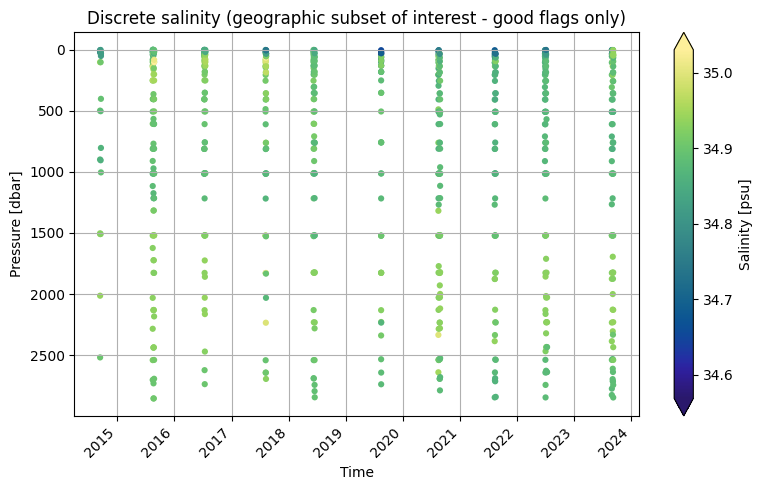

In [126]:
# plot code from JP class differs from initial plot code above
plt.figure(figsize=(8, 5))

plt.scatter(
    x=df_ctd_discr_spatial_erddapy_qc["CTD_Bottle_Closure_Time"],
    y=df_ctd_discr_spatial_erddapy_qc["CTD_Pressure"],
    s=20,
    c=df_ctd_discr_spatial_erddapy_qc["Discrete_Salinity"],
    cmap=cmo.haline,  # colormap from cmocean, designed for salinity (perceptually uniform, accessible colors)
    edgecolors="none",
    vmin=salmin_erddapy_qc, # use salmin
    vmax=salmax_erddapy_qc # use salmax
)

plt.gca().invert_yaxis()
plt.grid()
plt.colorbar(label="Salinity [psu]")
plt.ylabel("Pressure [dbar]")
plt.xlabel("Time")
plt.title("Discrete salinity (geographic subset of interest - good flags only)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

# Wrapping up session 1

Let's get some information we can use in our documentation.

### When did you access your data?

In a notebook cell it's a good idea to print out the date (or datetime) when you ran your code. That way you have it for when you ever need that information in your documentation.

In [127]:
from datetime import datetime

print("Run datetime: " + datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Run datetime: 2026-07-21 19:38:47


### What libarary versions did you use?

Below we are printing the package versions ran with this notebook notebook in case we ever need to look back at this run and know when and what we were working with.  

In [128]:
from importlib.metadata import version

print("\nThis notebook was run with:")

print("erddapy version: " + version("erddapy"))
print("pandas version: " + version("pandas"))
print("matplotlib version: " + version("matplotlib"))
print("cmocean version: " + version("cmocean"))

# Above we just asked for main package versions, but even better is saving a
#     requierments.txt file wich you can write with:
# !pip freeze > requirements.txt
#    will write you a file with ALL versions of everything in your environment



This notebook was run with:
erddapy version: 3.3.0
pandas version: 2.2.2
matplotlib version: 3.10.0
cmocean version: 4.0.3


## Record your data citation

Record a data citation for any data sources you used.  This is a good practice for what to provide in reports, publications, or journal articles you might publish that used these data.

It's also valuable for the "future you" to have this record in case you want to come back later and work with these data again.

### From a BCO-DMO page:

 You can get the suggeted citation for the BCO-DMO data (or subset) used by clicking the "Cite Dataset" button on the top right of the Dataset Landing Page: https://www.bco-dmo.org/dataset/911407

### From any ERDDAP server:

If you are using data from an ERDDAP server, you can check out this page which has some additional information about where you can find citation information from ERDDAP pages https://erddap.bco-dmo.org/erddap/information.html#citeDataset which suggests looking at the ERDDAP dataset metadata page.

* For example this is the metadata page for our dataset of interest where you can find the metadata you'd include in a citation https://erddap.bco-dmo.org/erddap/info/bcodmo_dataset_911407_v1/index.html

# Additional Exercises

Let's put what we learned into practice by accessing an additional dataset and plotting it together with the data we already worked with.  

### SUPPLEMENTARY DATASET for Session 1

Dataset: Bottle-calibrated dissolved oxygen profiles from yearly turn-around cruises for the Ocean Observations Initiative (OOI) Irminger Sea Array 2014 - 2022

* BCO-DMO dataset landing page: https://www.bco-dmo.org/dataset/904721
* ERDDAP page for dataset: https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_904721_v1.html



Exercises
*   Overlay one post-calibrated CTD profile from the supplementary dataset
*   Overlay all matching post-calibrated CTD profiles

In [ ]:
## TODO put exercise examples with hidden cell styles